#  Clasificación Multiclase con PyTorch
## Tabular Playground Series — May 2021 (Kaggle)

> **Disertación:** Este cuadernillo explica **paso a paso** cómo entrenar una red neuronal  
> profunda con PyTorch para clasificar 4 categorías de productos de e-commerce.

---

###  ¿Qué aprenderemos aquí?

| Concepto | Fuente |
|---|---|
| `nn.Module` con capas expandidas + BatchNorm | Cuadernillo **00** |
| Búsqueda de hiperparámetros con `ray[tune]` | Cuadernillo **00** |
| `Dataset` + `DataLoader` con mini-batches | Cuadernillo **03** |
| Checkpoints automáticos del mejor modelo | Cuadernillo **04** |
| `ReduceLROnPlateau` + Early Stopping | Cuadernillo **02/04** |
| Visualización de arquitectura, métricas, convergencia | Todos |

---

###  Dataset
- **Fuente:** [TPS May-2021 — Kaggle](https://www.kaggle.com/c/tabular-playground-series-may-2021/data)
- **Tamaño:** 200,000 muestras · 50 features numéricas · 4 clases
- **Problema:** Dataset sintético de e-commerce — features anónimas, sin nulos



---
##  Paso 0 — Instalación de dependencias

Instalamos `ray[tune]` para la búsqueda de hiperparámetros (igual que en el cuadernillo 00)  
y `tqdm` para barras de progreso visuales.

> **¿Por qué `ray[tune]`?**  
> En vez de probar manualmente cada combinación de `lr`, `batch_size`, `activación`, etc.,  
> `ray.tune` hace un **grid search automático** y nos entrega la mejor configuración.


In [102]:
!pip install -q "ray[tune]" tqdm

---
## 📦 Paso 1 — Importar librerías

Importamos:
- **PyTorch** (`torch`, `nn`, `optim`) → red neuronal
- **ray.tune** → búsqueda de hiperparámetros automática (cuadernillo 00)
- **tqdm** → barra de progreso visual por época
- **sklearn** → split, normalización, métricas
- **matplotlib / seaborn** → gráficas


In [103]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils import resample
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, log_loss)

from ray import tune

# ── Reproducibilidad ──────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# ── Dispositivo: GPU si está disponible ──────────────────────
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'✔  Dispositivo activo: {device}')
print(f'✔  PyTorch version  : {torch.__version__}')

✔  Dispositivo activo: cuda
✔  PyTorch version  : 2.10.0+cu128


---
## 📂 Paso 2 — Cargar el dataset

Cargamos `train.csv` directamente desde Google Drive.  
Verificamos:
- ¿Cuántas filas/columnas hay?
- ¿Hay valores nulos?
- ¿Cómo se distribuyen las 4 clases?

> **Nota:** si el CSV ya está en el entorno local (Colab), descomenta la línea de Drive.


In [104]:
from google.colab import drive; drive.mount('/content/drive')
RUTA = '/content/drive/MyDrive/Universida/IA/Dataset/train.csv'


df = pd.read_csv(RUTA)
print(f'Dimensiones : {df.shape}')
print(f'Nulos totales: {df.isnull().sum().sum()}')
print()
print('Distribución de clases:')
print(df['target'].value_counts())
df.head(3)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dimensiones : (100000, 52)
Nulos totales: 0

Distribución de clases:
target
Class_2    57497
Class_3    21420
Class_4    12593
Class_1     8490
Name: count, dtype: int64


,id,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,...,feature_41,feature_42,feature_43,feature_44,feature_45,feature_46,feature_47,feature_48,feature_49,target
0,0,0,0,1,0,1,0,0,0,0,...,0,0,21,0,0,0,0,0,0,Class_2
1,1,0,0,0,0,2,1,0,0,0,...,0,0,0,0,0,0,0,0,0,Class_1
2,2,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,13,2,0,Class_1


---
##  Paso 3 — Exploración visual (EDA)

Antes de entrenar, siempre exploramos los datos:
1. Distribución de las 4 clases
2. Distribución de las primeras features (para ver si hay outliers)

> **¿Por qué?**  
> Si las clases están desbalanceadas, el modelo aprende a predecir siempre la clase mayoritaria.  
> Si las features tienen escalas muy distintas, el gradiente diverge.


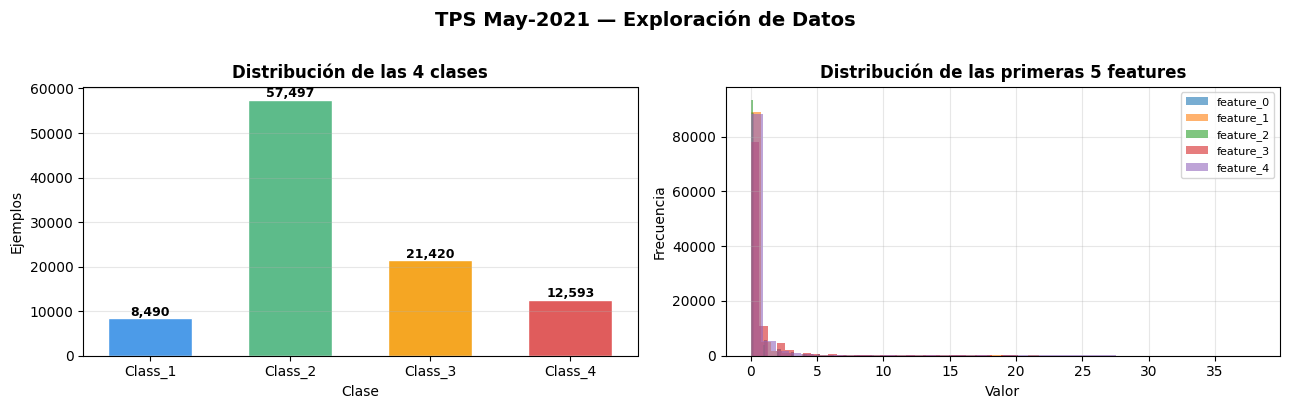

In [105]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# — Distribución de clases —
conteo = df['target'].value_counts().sort_index()
colores = ['#4C9BE8', '#5DBB8A', '#F5A623', '#E05C5C']
bars = axes[0].bar(conteo.index, conteo.values, color=colores, edgecolor='white', width=0.6)
for bar, v in zip(bars, conteo.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 500,
                 f'{v:,}', ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('Distribución de las 4 clases', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Clase'); axes[0].set_ylabel('Ejemplos')
axes[0].grid(axis='y', alpha=0.3)

# — Distribución de features 0–4 —
cols_feat = [f'feature_{i}' for i in range(5)]
for i, col in enumerate(cols_feat):
    axes[1].hist(df[col], bins=40, alpha=0.6, label=col)
axes[1].set_title('Distribución de las primeras 5 features', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Valor'); axes[1].set_ylabel('Frecuencia')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.suptitle('TPS May-2021 — Exploración de Datos', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

---
##  Paso 4 — Preprocesamiento

### 4.1 Balanceo de clases (Undersampling)

usamos undersampling: reducimos todas las clases  
al tamaño de la **clase minoritaria** para que el modelo no favorezca ninguna.

$$n_{\text{min}} = \min(|C_0|, |C_1|, |C_2|, |C_3|)$$

### 4.2 Normalización Z-score

Cada feature se normaliza con:
$$x_{\text{norm}} = \frac{x - \mu}{\sigma}$$

> **Importante:** calculamos μ y σ **solo en train**, y los aplicamos en test.  
> Esto evita el **data leakage** (que el modelo "vea" información del test durante el entrenamiento).


In [106]:
# ── 4.1 Undersampling ─────────────────────────────────────────
min_n  = df['target'].value_counts().min()
df_bal = pd.concat([
    resample(df[df['target'] == c], n_samples=min_n,
             replace=False, random_state=SEED)
    for c in df['target'].unique()
]).sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f'Clase mínima      : {min_n:,}')
print(f'Total balanceado  : {len(df_bal):,}')
print(df_bal['target'].value_counts())

Clase mínima      : 8,490
Total balanceado  : 33,960
target
Class_3    8490
Class_4    8490
Class_2    8490
Class_1    8490
Name: count, dtype: int64


In [107]:
# ── 4.2 Features, etiquetas y split ──────────────────────────
COLS = [f'feature_{i}' for i in range(50)]
le   = LabelEncoder()

X    = df_bal[COLS].values.astype(np.float32)
y    = le.fit_transform(df_bal['target'])        # clases → enteros 0/1/2/3

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED)

# ── Normalización Z-score ─────────────────────────────────────
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)          # fit SOLO en train
X_test  = scaler.transform(X_test)               # transform en test

print(f'Train : {X_train.shape} | Test: {X_test.shape}')
print(f'Clases: {le.classes_}')
print(f'Post-normalización → media≈{X_train.mean():.3f}  std≈{X_train.std():.3f}')

Train : (27168, 50) | Test: (6792, 50)
Clases: ['Class_1' 'Class_2' 'Class_3' 'Class_4']
Post-normalización → media≈-0.000  std≈1.000


### 4.3 ¿Qué hace la normalización Z-score? — Visualización

Mostramos la **misma feature** antes y después de normalizar para que quede claro visualmente.


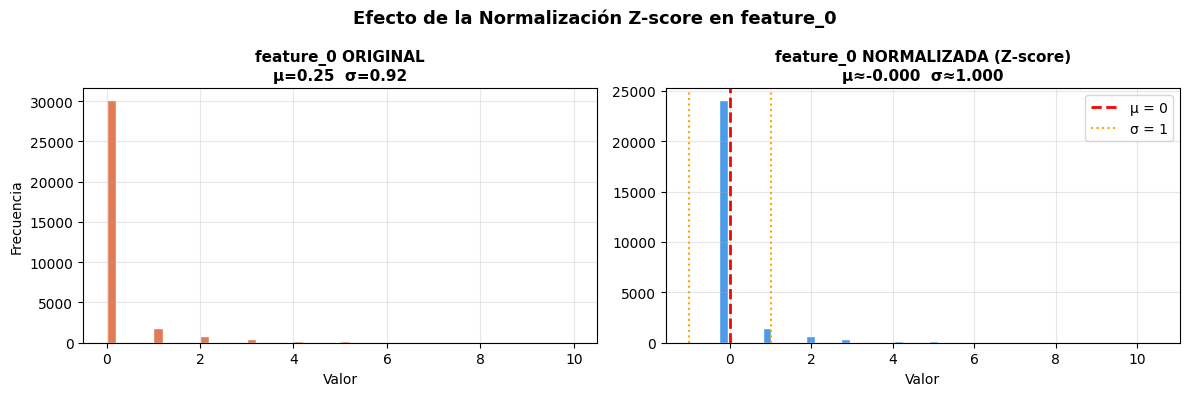

In [108]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Antes (valores originales)
raw_f0 = df_bal['feature_0'].values
axes[0].hist(raw_f0, bins=50, color='#E07B54', edgecolor='white')
axes[0].set_title(f'feature_0 ORIGINAL\nμ={raw_f0.mean():.2f}  σ={raw_f0.std():.2f}',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Valor'); axes[0].set_ylabel('Frecuencia')
axes[0].grid(alpha=0.3)

# Después (normalizado)
norm_f0 = X_train[:, 0]
axes[1].hist(norm_f0, bins=50, color='#4C9BE8', edgecolor='white')
axes[1].axvline(0, color='red', lw=2, linestyle='--', label='μ = 0')
axes[1].axvline(1, color='orange', lw=1.5, linestyle=':', label='σ = 1')
axes[1].axvline(-1, color='orange', lw=1.5, linestyle=':')
axes[1].set_title(f'feature_0 NORMALIZADA (Z-score)\nμ≈{norm_f0.mean():.3f}  σ≈{norm_f0.std():.3f}',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Valor'); axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Efecto de la Normalización Z-score en feature_0', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### 4.4 Balance de clases — antes vs después del undersampling


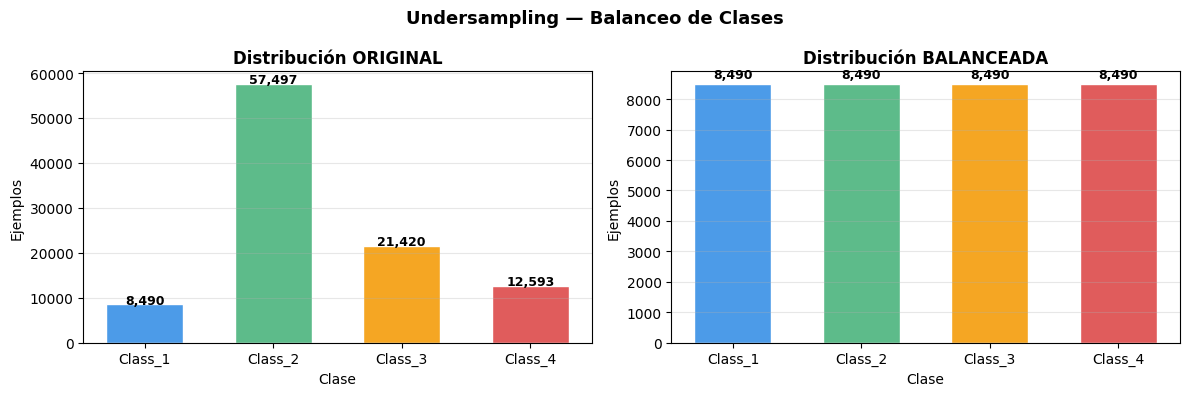

In [109]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colores = ['#4C9BE8','#5DBB8A','#F5A623','#E05C5C']

orig = df['target'].value_counts().sort_index()
bal  = df_bal['target'].value_counts().sort_index()

for ax, datos, titulo in zip(axes, [orig, bal],
                              ['Distribución ORIGINAL', 'Distribución BALANCEADA']):
    bars = ax.bar(datos.index, datos.values, color=colores, edgecolor='white', width=0.6)
    for bar, v in zip(bars, datos.values):
        ax.text(bar.get_x() + bar.get_width()/2, v + 200,
                f'{v:,}', ha='center', fontsize=9, fontweight='bold')
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.set_xlabel('Clase'); ax.set_ylabel('Ejemplos')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Undersampling — Balanceo de Clases', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---
## 🗂 Paso 5 — `Dataset` y `DataLoader` (cuadernillo 03)

### ¿Por qué usar `Dataset` y `DataLoader`?

El cuadernillo **03** nos enseña que en vez de iterar manualmente los datos:
```python
# Forma manual (cuadernillo 00)
for idx in range(0, len(X_train), batch_size):
    X_batch = X_train[idx:idx+batch_size]
```

Es mejor usar la clase `Dataset` de PyTorch, que:
- Maneja el **shuffle** automáticamente cada época
- Permite **mini-batches** de forma eficiente
- Es **reutilizable** para train, val y predicción

```
Dataset ──► DataLoader ──► mini-batches automáticos ──► modelo
```


In [110]:
class TPSDataset(Dataset):
    """
    Dataset tabular para TPS May-2021.
    Hereda de torch.utils.data.Dataset (cuadernillo 03).
    Implementa los tres métodos obligatorios:
      __init__  → guarda X e y como tensores
      __len__   → devuelve el número de muestras
      __getitem__→ devuelve un par (X[i], y[i])
    """
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)     # long para CrossEntropyLoss

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        return self.X[i], self.y[i]

# Instanciar datasets
ds_train = TPSDataset(X_train, y_train)
ds_test  = TPSDataset(X_test,  y_test)
print(f'Dataset train: {len(ds_train):,} muestras')
print(f'Dataset test : {len(ds_test):,} muestras')
print(f'Ejemplo [0]  : X={ds_train[0][0].shape}  y={ds_train[0][1]}')

Dataset train: 27,168 muestras
Dataset test : 6,792 muestras
Ejemplo [0]  : X=torch.Size([50])  y=2


In [111]:
# DataLoader: empaqueta el Dataset en mini-batches
# shuffle=True en train para evitar que el modelo aprenda el orden
dl_train = DataLoader(ds_train, batch_size=512, shuffle=True,  num_workers=0, pin_memory=True)
dl_test  = DataLoader(ds_test,  batch_size=512, shuffle=False, num_workers=0)

print(f'Batches por época (train): {len(dl_train)}')
print(f'Batches por época (test) : {len(dl_test)}')

# Verificar un batch
xb, yb = next(iter(dl_train))
print(f'\nEjemplo de batch → X: {xb.shape}  y: {yb.shape}')

Batches por época (train): 54
Batches por época (test) : 14

Ejemplo de batch → X: torch.Size([512, 50])  y: torch.Size([512])


---
##  Paso 6 — Arquitectura con `nn.Module` (estilo cuadernillo 00)

### ¿Por qué `nn.Module` en vez de `Sequential`?

El cuadernillo **00** define el modelo como clase que hereda de `nn.Module`.  
Esto da **control total** del `forward` y permite:
- Capas con nombres descriptivos (`self.fc1`, `self.fc2batchnorm`...)
- Arquitecturas no lineales (residuales, ramas múltiples)
- Fácil acceso a parámetros individuales

### Arquitectura expandida (patrón del cuadernillo 00)

El modelo del cuadernillo 00 **expande** la dimensión hasta un máximo y luego **la reduce**:

```
Input(50) → starter(s) → s×2 → s×4 → s×2 → Output(4)
               ↑ BN+Act  ↑BN+Act ↑BN+Act ↑BN+Act
```

Donde `starter` es un hiperparámetro a buscar (16, 32, 64, 128, 256, 512).


In [112]:
class ModelTPS(nn.Module):
    """
    Red neuronal tabular inspirada en el cuadernillo 00.
    Expande la dimensión hasta starter×4 y luego la reduce.

    Parámetros
    ----------
    input_dim  : número de features de entrada (50 para TPS)
    starter    : tamaño inicial de la capa oculta (hiperparámetro)
    n_classes  : número de clases de salida (4 para TPS)
    activation : función de activación (ReLU, LeakyReLU, ELU, SiLU...)
    dropout    : tasa de dropout para regularización
    """
    def __init__(self, input_dim=50, starter=64,
                 n_classes=4, activation=None, dropout=0.25):
        super().__init__()
        if activation is None:
            activation = nn.ReLU()
        self.activation = activation

        # — Bloque 1: input → starter —
        self.fc1      = nn.Linear(input_dim, starter)
        self.bn1      = nn.BatchNorm1d(starter)
        self.drop1    = nn.Dropout(dropout)

        # — Bloque 2: starter → starter×2 —
        self.fc2      = nn.Linear(starter, starter * 2)
        self.bn2      = nn.BatchNorm1d(starter * 2)
        self.drop2    = nn.Dropout(dropout)

        # — Bloque 3: starter×2 → starter×4 (expansión máxima) —
        self.fc3      = nn.Linear(starter * 2, starter * 4)
        self.bn3      = nn.BatchNorm1d(starter * 4)
        self.drop3    = nn.Dropout(dropout)

        # — Bloque 4: starter×4 → starter×2 (contracción) —
        self.fc4      = nn.Linear(starter * 4, starter * 2)
        self.bn4      = nn.BatchNorm1d(starter * 2)
        self.drop4    = nn.Dropout(dropout)

        # — Cabeza de salida —
        self.output   = nn.Linear(starter * 2, n_classes)

    def forward(self, x):
        # Bloque 1
        x = self.drop1(self.activation(self.bn1(self.fc1(x))))
        # Bloque 2
        x = self.drop2(self.activation(self.bn2(self.fc2(x))))
        # Bloque 3
        x = self.drop3(self.activation(self.bn3(self.fc3(x))))
        # Bloque 4
        x = self.drop4(self.activation(self.bn4(self.fc4(x))))
        # Salida (logits crudos → CrossEntropyLoss aplica Softmax)
        return self.output(x)

# Prueba rápida con starter=64
model_test = ModelTPS(input_dim=50, starter=64)
dummy = torch.randn(8, 50)
out   = model_test(dummy)
print(f'Output shape: {out.shape}  (esperado: [8, 4])')
total_params = sum(p.numel() for p in model_test.parameters() if p.requires_grad)
print(f'Parámetros entrenables (starter=64): {total_params:,}')

Output shape: torch.Size([8, 4])  (esperado: [8, 4])
Parámetros entrenables (starter=64): 79,172


### 6.2 Visualización de la arquitectura por capas

Dibujamos las capas del modelo con sus dimensiones para visualizar la expansión y contracción.


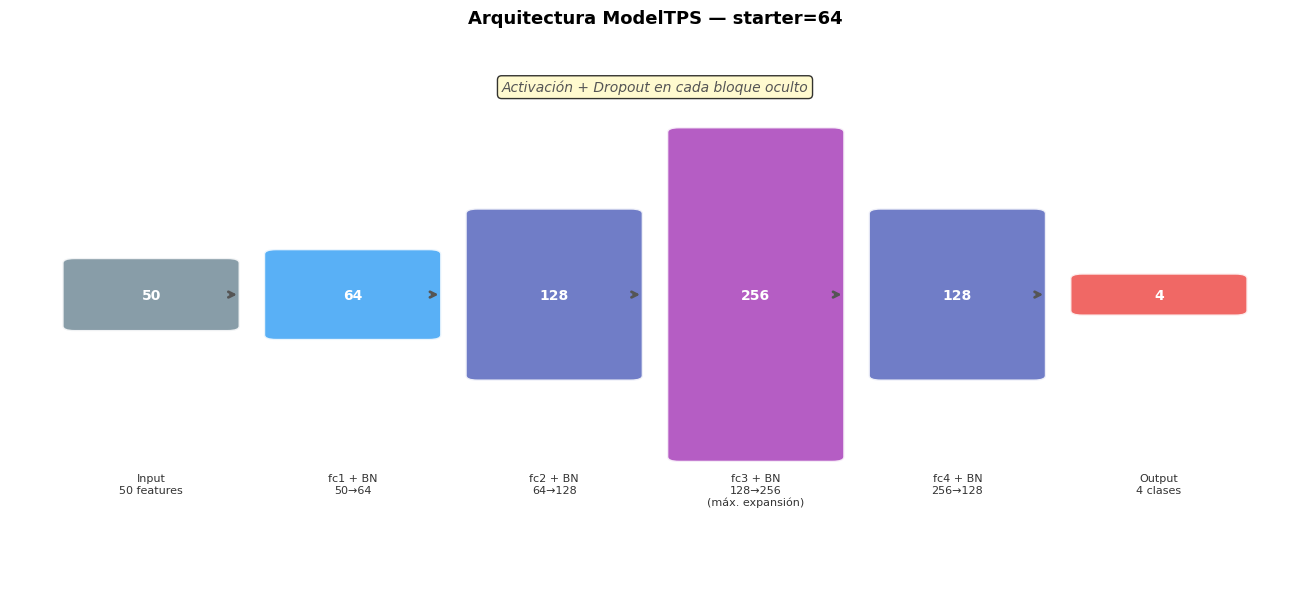

In [113]:
def plot_architecture_tps(starter=64, input_dim=50, n_classes=4, title=None):
    """Visualiza la arquitectura expandida del cuadernillo 00."""
    dims   = [input_dim, starter, starter*2, starter*4, starter*2, n_classes]
    labels = [
        f'Input\n{input_dim} features',
        f'fc1 + BN\n{input_dim}→{starter}',
        f'fc2 + BN\n{starter}→{starter*2}',
        f'fc3 + BN\n{starter*2}→{starter*4}\n(máx. expansión)',
        f'fc4 + BN\n{starter*4}→{starter*2}',
        f'Output\n{n_classes} clases'
    ]
    colors = ['#78909C','#42A5F5','#5C6BC0','#AB47BC','#5C6BC0','#EF5350']

    n   = len(dims)
    fig, ax = plt.subplots(figsize=(n*2.2, 6))
    ax.set_xlim(-0.7, n-0.3); ax.set_ylim(-1.5, 5); ax.axis('off')
    mx = max(dims)

    for i, (d, lbl, col) in enumerate(zip(dims, labels, colors)):
        h = max(0.4, d / mx * 4)
        rect = mpatches.FancyBboxPatch(
            (i - 0.38, 2 - h/2), 0.76, h,
            boxstyle='round,pad=0.06', facecolor=col,
            alpha=0.88, edgecolor='white', lw=1.8)
        ax.add_patch(rect)
        ax.text(i, 2, str(d), ha='center', va='center',
                fontsize=10, fontweight='bold', color='white')
        ax.text(i, -0.2, lbl, ha='center', va='top',
                fontsize=8, color='#333', multialignment='center')
        if i < n-1:
            ax.annotate('', xy=(i+0.44, 2), xytext=(i+0.38, 2),
                        arrowprops=dict(arrowstyle='->', color='#555', lw=2))

    # Etiqueta de activación
    ax.text(n/2-0.5, 4.5,
            'Activación + Dropout en cada bloque oculto',
            ha='center', fontsize=10, color='#555', style='italic',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFF9C4', alpha=0.8))

    if title is None:
        title = f'Arquitectura ModelTPS — starter={starter}'
    ax.set_title(title, fontsize=13, fontweight='bold', pad=20)
    plt.tight_layout(); plt.show()

# Visualizar con starter=64
plot_architecture_tps(starter=64)

### 6.3 Comparativa de arquitecturas con distintos `starter`

Mostramos cómo cambia la red al variar `starter`.


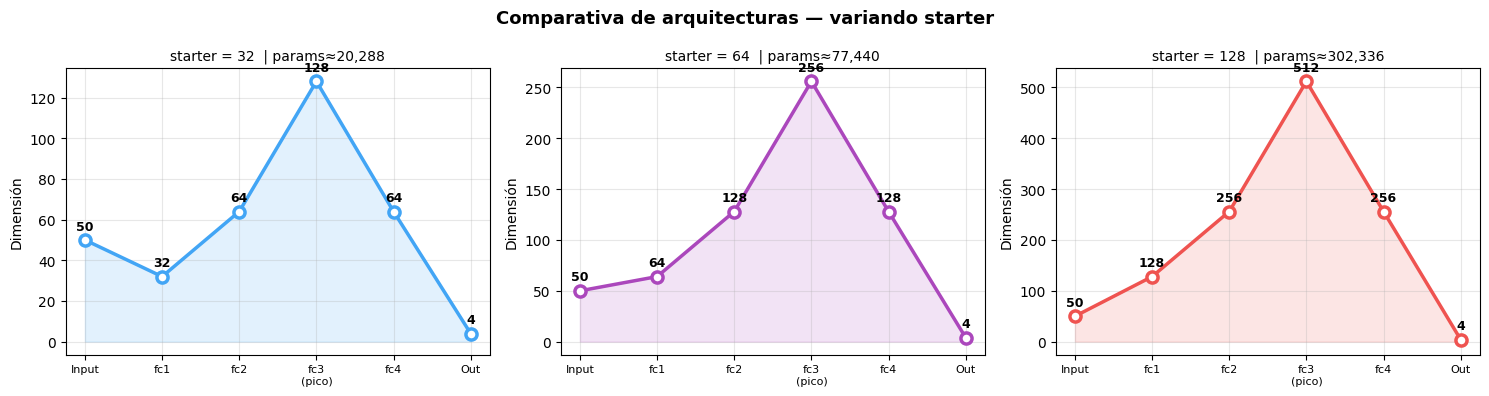

In [114]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
starters = [32, 64, 128]
colores_s = ['#42A5F5','#AB47BC','#EF5350']

for ax, s, col in zip(axes, starters, colores_s):
    dims = [50, s, s*2, s*4, s*2, 4]
    x    = list(range(len(dims)))
    ax.plot(x, dims, 'o-', color=col, lw=2.5, markersize=8, markerfacecolor='white',
            markeredgewidth=2.5)
    ax.fill_between(x, dims, alpha=0.15, color=col)
    for xi, d in zip(x, dims):
        ax.text(xi, d + max(dims)*0.04, str(d), ha='center', fontsize=9, fontweight='bold')
    ax.set_title(f'starter = {s}  | params≈{50*s + s*s*2 + s*2*s*4 + s*4*s*2 + s*2*4:,}',
                 fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(['Input','fc1','fc2','fc3\n(pico)','fc4','Out'], fontsize=8)
    ax.set_ylabel('Dimensión'); ax.grid(alpha=0.3)

plt.suptitle('Comparativa de arquitecturas — variando starter', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---
##  Paso 7 — Función `evaluate` (equivalente a `test` del cuadernillo 00)

El cuadernillo **00** separa el cálculo del accuracy en una función independiente `test()`.  
La adaptamos para multiclase (4 clases) usando `DataLoader` para mayor eficiencia.

```python
# Cuadernillo 00 (original — una muestra a la vez)
for idx in range(len(X_test)):
    preds = model(X_test[idx].view(1, 10))

# Nuestra versión — DataLoader (por batches, más rápido)
for xb, yb in dl_test:
    preds = model(xb)
```


In [115]:
def evaluate(model, dl, device='cpu'):
    """
    Calcula accuracy y log-loss sobre un DataLoader.
    """
    model.eval()
    all_preds, all_probs, all_labels = [], [], []
    with torch.no_grad():
        for xb, yb in dl:
            xb = xb.to(device)
            logits = model(xb)
            probs  = torch.softmax(logits, dim=1).cpu().numpy()
            preds  = logits.argmax(dim=1).cpu().numpy()
            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels.extend(yb.numpy())
    model.train()   # volver a modo entrenamiento (como en cuadernillo 00)

    acc  = accuracy_score(all_labels, all_preds)
    loss = log_loss(all_labels, all_probs)
    return acc, loss, np.array(all_preds), np.array(all_labels)

print('✔  Función evaluate() definida')

✔  Función evaluate() definida


---
##  Paso 8 — Búsqueda de hiperparámetros con `ray.tune` (cuadernillo 00)

### ¿Qué es `ray.tune`?

En el cuadernillo **00**, en vez de elegir manualmente los hiperparámetros,  
se hace un **grid search** automático probando todas las combinaciones de:

| Hiperparámetro | Opciones a probar |
|---|---|
| `starter` (tamaño capa) | 32, 64, 128 |
| `activation` (función activación) | ReLU, LeakyReLU, ELU, SiLU |
| `optimizer` | Adam, AdamW |
| `lr` (learning rate) | 1e-3, 1e-4 |
| `criterion` (función de pérdida) | CrossEntropyLoss |

>  **Para disertación:** usamos un grid pequeño para que sea rápido.  
> En producción (cuadernillo 00 completo) se pueden probar cientos de combinaciones.


In [116]:
def train_tune(config):
    """
    Función de entrenamiento para ray.tune.
    Recibe 'config' con los hiperparámetros a probar.
    Reporta accuracy al tune para que encuentre el mejor config.
    """
    # ── Construir modelo con los hiperparámetros del config ──
    model = ModelTPS(
        input_dim  = 50,
        starter    = config['starter'],
        n_classes  = 4,
        activation = config['activation'](), # Instantiate the activation function here
        dropout    = config.get('dropout', 0.25)
    ).to(device)

    criterion = config['criterion']()
    optimizer = config['optimizer'](model.parameters(), lr=config['lr'])

    # ── Mini-loop de entrenamiento (épocas rápidas para el search) ──
    batch_size = config['batch_size']
    X_tr_t = torch.tensor(X_train, dtype=torch.float32)
    y_tr_t = torch.tensor(y_train, dtype=torch.long)

    model.train()
    for epoch in range(config['epochs']):
        # Mini-batches manuales (estilo cuadernillo 00)
        idxs = torch.randperm(len(X_tr_t))
        X_sh, y_sh = X_tr_t[idxs], y_tr_t[idxs]

        for i in range(0, len(X_sh), batch_size):
            xb = X_sh[i:i+batch_size].to(device)
            yb = y_sh[i:i+batch_size].to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

    # ── Evaluar y reportar ──
    acc, val_loss, _, _ = evaluate(model, dl_test, device)
    tune.report(metrics={"accuracy": acc, "val_loss": val_loss})

In [ ]:
# ── Configuración del grid search (igual que cuadernillo 00) ──
search_config = {
    'epochs'    : tune.grid_search([15]),                   # épocas rápidas para el search
    'batch_size': tune.grid_search([512]),
    'criterion' : tune.grid_search([nn.CrossEntropyLoss]),
    'starter'   : tune.grid_search([32, 64, 128]),
    'activation': tune.grid_search([nn.ReLU, nn.LeakyReLU, nn.ELU, nn.SiLU]), # Pass classes instead of instances
    'optimizer' : tune.grid_search([optim.Adam, optim.AdamW]),
    'lr'        : tune.grid_search([1e-3, 1e-4]),
    'dropout'   : tune.grid_search([0.2, 0.3]),
}

print('Configuración del Grid Search:')
print(f'  starter     : {[32, 64, 128]}')
print(f'  activation  : ReLU, LeakyReLU, ELU, SiLU')
print(f'  optimizer   : Adam, AdamW')
print(f'  lr          : 1e-3, 1e-4')
print(f'  dropout     : 0.2, 0.3')
print()
n_combos = 3 * 4 * 2 * 2 * 2
print(f'  Total combinaciones: {n_combos}')
print()
print('▶ Ejecutando ray.tune (esto puede tardar varios minutos)...')

analysis = tune.run(
    train_tune,
    config    = search_config,
    verbose   = 0,
    resources_per_trial = {'gpu': 1 if device == 'cuda' else 0, 'cpu': 2},
)

print('✔  Búsqueda completada')

Configuración del Grid Search:
  starter     : [32, 64, 128]
  activation  : ReLU, LeakyReLU, ELU, SiLU
  optimizer   : Adam, AdamW
  lr          : 1e-3, 1e-4
  dropout     : 0.2, 0.3

  Total combinaciones: 96

▶ Ejecutando ray.tune (esto puede tardar varios minutos)...
+-------------------------------------------------------------------+
| Configuration for experiment     train_tune_2026-03-31_06-11-59   |
+-------------------------------------------------------------------+
| Search algorithm                 BasicVariantGenerator            |
| Scheduler                        FIFOScheduler                    |
| Number of trials                 96                               |
+-------------------------------------------------------------------+

View detailed results here: /root/ray_results/train_tune_2026-03-31_06-11-59
To visualize your results with TensorBoard, run: `tensorboard --logdir /tmp/ray/session_2026-03-31_04-19-12_247215_3335/artifacts/2026-03-31_06-11-59/train_tune

2026-03-31 06:12:48,443	INFO tensorboardx.py:308 -- Removed the following hyperparameter values when logging to tensorboard: {'activation': ('__ref_ph', '8b584001'), 'criterion': ('__ref_ph', '6b43ffe6'), 'optimizer': ('__ref_ph', 'a5359e99')}
(train_tune pid=58217) /usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
(train_tune pid=58217)   warnings.warn(
2026-03-31 06:13:09,628	INFO tensorboardx.py:308 -- Removed the following hyperparameter values when logging to tensorboard: {'activation': ('__ref_ph', 'bd581d64'), 'criterion': ('__ref_ph', '6b43ffe6'), 'optimizer': ('__ref_ph', 'a5359e99')}
(train_tune pid=58449) /usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
(train_tune pid=58449)   warnings.warn(
2026-03-31 06:13:26,952	INFO tensorboardx.py:308 -- Remove

In [ ]:
# ── Mejor configuración encontrada ──
best_config = analysis.get_best_config(metric='accuracy', mode='max')
print('🏆 Mejor configuración encontrada:')
for k, v in best_config.items():
    print(f'   {k:<12}: {v}')

### 8.1 Visualizar resultados del grid search

Mostramos los resultados de todas las combinaciones para entender qué hiperparámetros importan más.


In [ ]:
results_df = analysis.results_df[['config/starter','config/lr',
                                     'config/activation','config/optimizer',
                                     'accuracy','val_loss']].dropna()
results_df = results_df.sort_values('accuracy', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Accuracy por starter
for s, col in zip([32, 64, 128], ['#4C9BE8','#5DBB8A','#F5A623']):
    sub = results_df[results_df['config/starter'] == s]['accuracy']
    axes[0].scatter([s]*len(sub), sub*100, color=col, alpha=0.7, s=60, label=f'starter={s}')
axes[0].set_title('Accuracy según tamaño de red (starter)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('starter'); axes[0].set_ylabel('Accuracy (%)')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Accuracy por lr
for lr_val, col in zip([1e-3, 1e-4], ['#AB47BC','#EF5350']):
    sub = results_df[results_df['config/lr'] == lr_val]['accuracy']
    axes[1].boxplot(sub*100, positions=[list([1e-3,1e-4]).index(lr_val)],
                   patch_artist=True,
                   boxprops=dict(facecolor=col, alpha=0.7))
axes[1].set_xticks([0, 1]); axes[1].set_xticklabels(['lr=1e-3','lr=1e-4'])
axes[1].set_title('Distribución de Accuracy por Learning Rate', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Accuracy (%)'); axes[1].grid(alpha=0.3)

plt.suptitle('Ray Tune — Resultados del Grid Search', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print('\nTop 5 configuraciones:')
print(results_df.head(5).to_string(index=False))

---
## 🚀 Paso 9 — Entrenamiento final con la mejor configuración

Ahora que `ray.tune` encontró la mejor configuración, entrenamos el modelo final  
con **más épocas** y todas las técnicas del cuadernillo **02/03/04**:

- `tqdm` para barra de progreso (cuadernillo 00)
- `ReduceLROnPlateau` — scheduler adaptativo (cuadernillo 04)
- **Early stopping** — para cuando deja de mejorar
- **Checkpoint** automático del mejor modelo (cuadernillo 04)


In [ ]:
# ── Construir modelo final con la mejor configuración ─────────
model = ModelTPS(
    input_dim  = 50,
    starter    = best_config['starter'],
    n_classes  = 4,
    activation = best_config['activation'],
    dropout    = best_config.get('dropout', 0.25)
).to(device)

criterion  = best_config['criterion']()
optimizer  = best_config['optimizer'](model.parameters(), lr=best_config['lr'],
                                       weight_decay=1e-4)
scheduler  = ReduceLROnPlateau(optimizer, mode='min', factor=0.5,
                                patience=5, verbose=True)

EPOCHS      = 100
PATIENCE    = 15
CHECKPOINT  = 'tps_best.pt'     # cuadernillo 04

total_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Modelo final — starter={best_config["starter"]}')
print(f'Parámetros entrenables: {total_p:,}')
print(f'Épocas máximas: {EPOCHS}  |  Early stopping: {PATIENCE}')

In [ ]:
# ── Loop de entrenamiento con tqdm + checkpoint ───────────────
history = []
best_val_loss = float('inf')
no_improve    = 0

for epoch in tqdm(range(1, EPOCHS + 1), desc='Entrenando'):
    # ── TRAIN ──
    model.train()
    train_losses = []
    for xb, yb in dl_train:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    # ── EVALUATE ──
    val_acc, val_loss, _, _ = evaluate(model, dl_test, device)
    train_loss = np.mean(train_losses)
    scheduler.step(val_loss)

    # ── CHECKPOINT (cuadernillo 04) ──
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        no_improve    = 0
        torch.save({
            'epoch'      : epoch,
            'state_dict' : model.state_dict(),
            'optimizer'  : optimizer.state_dict(),
            'val_loss'   : val_loss,
            'val_acc'    : val_acc,
        }, CHECKPOINT)
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f'\n  Early stop en época {epoch}')
            break

    history.append({
        'epoch'     : epoch,
        'train_loss': train_loss,
        'val_loss'  : val_loss,
        'val_acc'   : val_acc,
        'lr'        : optimizer.param_groups[0]['lr'],
    })

# ── Cargar mejor checkpoint (cuadernillo 04) ──────────────────
ckpt = torch.load(CHECKPOINT, map_location=device)
model.load_state_dict(ckpt['state_dict'])
print(f'\n✔ Mejor modelo cargado — época {ckpt["epoch"]}')
print(f'  val_loss = {ckpt["val_loss"]:.4f}')
print(f'  val_acc  = {ckpt["val_acc"]:.4f} ({ckpt["val_acc"]*100:.2f}%)')

---
##  Paso 10 — Visualizar el entrenamiento

Graficamos por separado (una gráfica por celda) la evolución de:
1. La función de pérdida (train vs val)
2. El accuracy de validación
3. El learning rate (schedule)

> **¿Por qué separadas?** Para que en la disertación cada gráfica tenga  
> su propia explicación y no se mezclen los conceptos.


In [ ]:
# ── 10.1 Curva de pérdida ─────────────────────────────────────
ep    = [h['epoch']      for h in history]
tr_l  = [h['train_loss'] for h in history]
val_l = [h['val_loss']   for h in history]

plt.figure(figsize=(10, 4))
plt.plot(ep, tr_l,  lw=2.5, color='#4C9BE8', label='Train Loss')
plt.plot(ep, val_l, lw=2.5, color='#E05C5C', linestyle='--', label='Val Loss')
plt.fill_between(ep, tr_l, val_l, alpha=0.08, color='gray')

# Marcar el mejor checkpoint
best_ep = ckpt['epoch']
plt.axvline(best_ep, color='green', lw=1.5, linestyle=':', label=f'Best checkpoint (ep {best_ep})')

plt.title('Curva de Pérdida — CrossEntropyLoss', fontsize=13, fontweight='bold')
plt.xlabel('Época'); plt.ylabel('Pérdida')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

In [ ]:
# ── 10.2 Curva de Accuracy ───────────────────────────────────
val_a = [h['val_acc']*100 for h in history]

plt.figure(figsize=(10, 4))
plt.plot(ep, val_a, lw=2.5, color='#5DBB8A', label='Val Accuracy (%)')
plt.axvline(best_ep, color='green', lw=1.5, linestyle=':', label=f'Best (ep {best_ep})')
plt.axhline(ckpt['val_acc']*100, color='orange', lw=1.2, linestyle='--',
            label=f'Mejor acc = {ckpt["val_acc"]*100:.2f}%')

plt.title('Accuracy de Validación por Época', fontsize=13, fontweight='bold')
plt.xlabel('Época'); plt.ylabel('Accuracy (%)')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

In [ ]:
# ── 10.3 Learning Rate schedule ──────────────────────────────
lrs = [h['lr'] for h in history]

plt.figure(figsize=(10, 3))
plt.plot(ep, lrs, lw=2.5, color='#F5A623')
plt.title('Learning Rate — ReduceLROnPlateau', fontsize=13, fontweight='bold')
plt.xlabel('Época'); plt.ylabel('Learning Rate')
plt.yscale('log'); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
print('Cuando el LR baja → el scheduler detectó que val_loss dejó de mejorar.')

---
##  Paso 11 — Evaluación final del modelo

Cargamos el mejor checkpoint y evaluamos con métricas completas:
- **Accuracy** global
- **Classification report** (precision, recall, F1 por clase)
- **Log-loss**


In [ ]:
final_acc, final_loss, preds_final, labels_final = evaluate(model, dl_test, device)
print('=' * 55)
print('           EVALUACIÓN FINAL')
print('=' * 55)
print(f'  Accuracy  : {final_acc:.4f}  ({final_acc*100:.2f}%)')
print(f'  Log-Loss  : {final_loss:.4f}')
print()
print(classification_report(labels_final, preds_final, target_names=le.classes_))

---
##  Paso 12 — Métricas visuales

### 12.1 Matriz de confusión

Muestra cuántos ejemplos de cada clase **real** fueron predichos en cada clase.  
La diagonal = predicciones correctas.


In [ ]:
cm = confusion_matrix(labels_final, preds_final)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=0.5, linecolor='white')
plt.title('Matriz de Confusión — TPS May-2021', fontsize=13, fontweight='bold')
plt.ylabel('Clase Real', fontsize=11); plt.xlabel('Clase Predicha', fontsize=11)
plt.tight_layout(); plt.show()

### 12.2 Accuracy por clase

In [ ]:
acc_por_clase = cm.diagonal() / cm.sum(axis=1)
plt.figure(figsize=(8, 4))
bars = plt.bar(le.classes_, acc_por_clase * 100,
               color=['#4C9BE8','#5DBB8A','#F5A623','#E05C5C'],
               edgecolor='white', width=0.5)
for bar, v in zip(bars, acc_por_clase):
    plt.text(bar.get_x() + bar.get_width()/2, v*100 + 0.5,
             f'{v*100:.1f}%', ha='center', fontsize=10, fontweight='bold')
plt.ylim(0, 110)
plt.title('Accuracy por Clase', fontsize=13, fontweight='bold')
plt.xlabel('Clase'); plt.ylabel('Accuracy (%)')
plt.axhline(final_acc*100, color='gray', lw=1.5, linestyle='--', label=f'Promedio {final_acc*100:.1f}%')
plt.legend(); plt.grid(axis='y', alpha=0.3); plt.tight_layout(); plt.show()

### 12.3 Distribución de probabilidades Softmax por clase

In [ ]:
model.eval()
all_probs = []
with torch.no_grad():
    for xb, _ in dl_test:
        logits = model(xb.to(device))
        all_probs.extend(torch.softmax(logits, dim=1).cpu().numpy())
all_probs = np.array(all_probs)

fig, axes = plt.subplots(1, len(le.classes_), figsize=(14, 4), sharey=True)
pal = ['#4C9BE8','#5DBB8A','#F5A623','#E05C5C']
for i, (cls, col) in enumerate(zip(le.classes_, pal)):
    axes[i].hist(all_probs[:, i], bins=40, color=col, edgecolor='white', alpha=0.9)
    axes[i].set_title(f'P(clase={cls})', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Probabilidad Softmax'); axes[i].grid(alpha=0.3)
axes[0].set_ylabel('Frecuencia')
plt.suptitle('Distribución de Probabilidades Softmax por Clase', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---
##  Paso 13 — Cómo cargar el checkpoint (cuadernillo 04)

El cuadernillo **04** nos enseña que el `state_dict` guarda **solo los pesos**,  
lo que es más eficiente que guardar el modelo completo.

```python
# Guardar (ya lo hicimos durante el entrenamiento)
torch.save({'state_dict': model.state_dict(), ...}, 'tps_best.pt')

# Cargar en cualquier momento (incluso en otra sesión)
ckpt  = torch.load('tps_best.pt')
model = ModelTPS(input_dim=50, starter=..., ...)   # misma arquitectura
model.load_state_dict(ckpt['state_dict'])
model.eval()
```


In [ ]:
# Verificar el contenido del checkpoint
ckpt_info = torch.load(CHECKPOINT, map_location='cpu')
print('Contenido del checkpoint guardado:')
for k, v in ckpt_info.items():
    if k == 'state_dict':
        n_tensors = len(v)
        total_w   = sum(p.numel() for p in v.values())
        print(f'  {k:<15}: {n_tensors} tensores | {total_w:,} pesos')
    else:
        print(f'  {k:<15}: {v}')

print()
print(f'Archivo guardado en: {CHECKPOINT}')

In [ ]:
# Demostración: cargar el checkpoint y hacer una predicción
model_loaded = ModelTPS(
    input_dim  = 50,
    starter    = best_config['starter'],
    n_classes  = 4,
    activation = best_config['activation'],
).to(device)

ckpt_loaded = torch.load(CHECKPOINT, map_location=device)
model_loaded.load_state_dict(ckpt_loaded['state_dict'])
model_loaded.eval()

# Predicción sobre las primeras 5 muestras del test
x_sample = torch.tensor(X_test[:5], dtype=torch.float32).to(device)
with torch.no_grad():
    logits  = model_loaded(x_sample)
    probs   = torch.softmax(logits, dim=1)
    pred_cl = logits.argmax(dim=1).cpu().numpy()

print('Predicciones sobre 5 muestras del test:')
print(f'  Clases disponibles : {le.classes_}')
print(f'  Predicciones (idx) : {pred_cl}')
print(f'  Predicciones (lbl) : {le.inverse_transform(pred_cl)}')
print(f'  Real               : {le.inverse_transform(y_test[:5])}')
print()
print('Probabilidades Softmax:')
for i, p in enumerate(probs.cpu().numpy()):
    print(f'  muestra {i}: {dict(zip(le.classes_, [f"{v:.3f}" for v in p]))}')

---
---
# 🏟 Tarea 1 — Clasificación Binaria: FIFA Player Stats
## ¿Es un jugador de FIFA élite? (Overall ≥ 80)

> **Disertación:** Aplicamos la misma arquitectura `nn.Module` del cuadernillo 00  
> pero para un problema **binario**: predecir si un jugador es élite o no.

---

### 📦 Dataset
- **Fuente:** [FIFA Player Stats — Kaggle](https://www.kaggle.com/datasets/bryanb/fifa-player-stats-database)
- **Tamaño:** ~35,487 jugadores · 40 features numéricas
- **Variable objetivo:** `élite = 1` si `Overall ≥ 80`, `0` si no

### 🔑 Diferencias con Tarea 3
| Aspecto | Tarea 3 (TPS) | Tarea 1 (FIFA) |
|---|---|---|
| Clases | 4 | 2 (binario) |
| Pérdida | `CrossEntropyLoss` | `BCEWithLogitsLoss` (Sigmoide integrada) |
| Salida | 4 logits | 1 logit → `σ(z) > 0.5` |
| Features | 50 anónimas | 40 estadísticas de fútbol |


---
## 🏟 F1 — Cargar datos FIFA

Montamos Drive y cargamos el CSV combinado FIFA 17+18.


In [ ]:
# ── Montar Drive (Colab) ──────────────────────────────────────
# from google.colab import drive; drive.mount('/content/drive')
RUTA_FIFA = '/content/drive/MyDrive/Universida/IA/Dataset/Clasificacion/FIFA_17_18_combined.csv'
# RUTA_FIFA = './FIFA_17_18_combined.csv'   # ← local si prefieres

df_fifa = pd.read_csv(RUTA_FIFA)
print(f'Shape: {df_fifa.shape}')
print(f'Nulos: {df_fifa.isnull().sum().sum()}')
df_fifa.head(3)

### F2 — Exploración: distribución Overall y balance de clases

In [ ]:
FEATURES_FIFA = [
    'Age','Potential','Crossing','Finishing','HeadingAccuracy','ShortPassing',
    'Volleys','Dribbling','Curve','FKAccuracy','LongPassing','BallControl',
    'Acceleration','SprintSpeed','Agility','Reactions','Balance','ShotPower',
    'Jumping','Stamina','Strength','LongShots','Aggression','Interceptions',
    'Positioning','Vision','Penalties','Composure','Marking','StandingTackle',
    'SlidingTackle','GKDiving','GKHandling','GKKicking','GKPositioning',
    'GKReflexes','International Reputation','Weak Foot','Skill Moves','FIFA_Year'
]

df_f  = df_fifa[FEATURES_FIFA + ['Overall']].dropna()
y_raw = (df_f['Overall'] >= 80).astype(int).values
n_elite    = y_raw.sum()
n_no_elite = (y_raw == 0).sum()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histograma Overall
axes[0].hist(df_f['Overall'], bins=40, color='#4C9BE8', edgecolor='white')
axes[0].axvline(80, color='red', lw=2, linestyle='--', label='Umbral élite (80)')
axes[0].set_title('Distribución de Overall', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Overall'); axes[0].set_ylabel('Jugadores'); axes[0].legend()
axes[0].grid(alpha=0.3)

# Balance élite / no élite
axes[1].bar(['No élite (0)','Élite (1)'], [n_no_elite, n_elite],
            color=['#E05C5C','#5DBB8A'], edgecolor='white', width=0.5)
for i, v in enumerate([n_no_elite, n_elite]):
    axes[1].text(i, v + 100, f'{v:,}', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Balance de Clases', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Jugadores'); axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('FIFA — Exploración de Datos', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()
print(f'Élite (1): {n_elite:,}  |  No élite (0): {n_no_elite:,}')
print(f'Ratio     : {n_elite/len(y_raw)*100:.1f}% élite')

### F3 — Preprocesamiento y normalización Z-score

Para clasificación binaria **no** necesitamos undersampling porque el desbalance no es extremo.  
Usamos `BCEWithLogitsLoss` con `pos_weight` para compensar el desbalance.

> **`pos_weight`:** le dice al modelo que penalice más los errores en la clase minoritaria (élite).  
> `pos_weight = n_no_elite / n_elite`


In [ ]:
X_f = df_f[FEATURES_FIFA].values.astype(np.float32)
y_f = y_raw

X_ftr, X_fte, y_ftr, y_fte = train_test_split(
    X_f, y_f, test_size=0.2, stratify=y_f, random_state=SEED)

sc_f   = StandardScaler()
X_ftr  = sc_f.fit_transform(X_ftr)
X_fte  = sc_f.transform(X_fte)

# pos_weight para compensar desbalance (cuadernillo 00 usa class_weight en sklearn)
pos_weight_val = (y_ftr == 0).sum() / (y_ftr == 1).sum()
pos_weight_t   = torch.tensor([pos_weight_val], dtype=torch.float32).to(device)

print(f'Train : {X_ftr.shape} | Test: {X_fte.shape}')
print(f'Élite en train: {y_ftr.sum():,} / {len(y_ftr):,}')
print(f'pos_weight    : {pos_weight_val:.2f}  (penaliza {pos_weight_val:.1f}x más los errores en élite)')

### F4 — Visualización de la normalización

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

raw_age = df_f['Age'].values
axes[0].hist(raw_age, bins=30, color='#E07B54', edgecolor='white')
axes[0].set_title(f'Age ORIGINAL  μ={raw_age.mean():.1f}  σ={raw_age.std():.1f}',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Valor'); axes[0].set_ylabel('Frecuencia'); axes[0].grid(alpha=0.3)

norm_age = X_ftr[:, FEATURES_FIFA.index('Age')]
axes[1].hist(norm_age, bins=30, color='#4C9BE8', edgecolor='white')
axes[1].axvline(0, color='red',    lw=2, linestyle='--', label='μ = 0')
axes[1].axvline(1, color='orange', lw=1.5, linestyle=':', label='σ = 1')
axes[1].axvline(-1,color='orange', lw=1.5, linestyle=':')
axes[1].set_title(f'Age NORMALIZADA  μ≈{norm_age.mean():.3f}  σ≈{norm_age.std():.3f}',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Valor'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('FIFA — Normalización Z-score en feature "Age"', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### F5 — `Dataset` y `DataLoader` para FIFA (cuadernillo 03)

Reutilizamos el patrón del cuadernillo 03, adaptando `y` a `float32` para `BCEWithLogitsLoss`.


In [ ]:
class FIFADataset(Dataset):
    """Dataset binario FIFA — y es float32 para BCEWithLogitsLoss."""
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)   # ← float para BCE

    def __len__(self):           return len(self.X)
    def __getitem__(self, i):    return self.X[i], self.y[i]

dl_ftr = DataLoader(FIFADataset(X_ftr, y_ftr), batch_size=512, shuffle=True,
                    num_workers=0, pin_memory=(device=='cuda'))
dl_fte = DataLoader(FIFADataset(X_fte, y_fte), batch_size=512, shuffle=False, num_workers=0)

print(f'Batches train: {len(dl_ftr)} | Batches test: {len(dl_fte)}')
xb, yb = next(iter(dl_ftr))
print(f'Batch X: {xb.shape}  y: {yb.shape}  dtype_y: {yb.dtype}')

### F6 — Arquitectura `nn.Module` para clasificación binaria

Misma arquitectura expandida del cuadernillo 00, con salida de **1 neurona**.  
No aplicamos sigmoide en `forward` — la incluye `BCEWithLogitsLoss`.

```
σ(z) integrada en BCEWithLogitsLoss → numéricamente más estable
```


In [ ]:
class ModelFIFA(nn.Module):
    """
    Red neuronal binaria para FIFA.
    Igual estructura que cuadernillo 00 (expande → contrae).
    Salida: 1 logit (BCEWithLogitsLoss aplica σ internamente).
    """
    def __init__(self, input_dim=40, starter=64, activation=None, dropout=0.25):
        super().__init__()
        if activation is None: activation = nn.SiLU()
        self.act = activation

        self.fc1  = nn.Linear(input_dim, starter);      self.bn1 = nn.BatchNorm1d(starter)
        self.fc2  = nn.Linear(starter, starter*2);      self.bn2 = nn.BatchNorm1d(starter*2)
        self.fc3  = nn.Linear(starter*2, starter*4);    self.bn3 = nn.BatchNorm1d(starter*4)
        self.fc4  = nn.Linear(starter*4, starter*2);    self.bn4 = nn.BatchNorm1d(starter*2)
        self.drop = nn.Dropout(dropout)
        self.out  = nn.Linear(starter*2, 1)             # 1 logit → binario

    def forward(self, x):
        x = self.drop(self.act(self.bn1(self.fc1(x))))
        x = self.drop(self.act(self.bn2(self.fc2(x))))
        x = self.drop(self.act(self.bn3(self.fc3(x))))
        x = self.drop(self.act(self.bn4(self.fc4(x))))
        return self.out(x).squeeze()                    # sin sigmoide aquí

# Prueba rápida
_m = ModelFIFA(input_dim=40, starter=64).to(device)
_x = torch.randn(8, 40).to(device)
print(f'Output shape: {_m(_x).shape}  (esperado: [8])')
print(f'Parámetros  : {sum(p.numel() for p in _m.parameters() if p.requires_grad):,}')

### F7 — Visualización de la arquitectura FIFA

In [ ]:
plot_architecture_tps(starter=64, input_dim=40, n_classes=1,
                      title='FIFA — ModelFIFA Binaria (starter=64, salida: 1 logit → σ)')

### F8 — ¿Dónde está la Sigmoide de PyTorch?

Para clasificación **binaria** usamos `BCEWithLogitsLoss` que **incluye la sigmoide** internamente.  
Al momento de predecir, la aplicamos explícitamente con `torch.sigmoid()`.

$$P(\text{élite}) = \sigma(\text{logit}) = \frac{1}{1+e^{-z}}$$

Si $P > 0.5$ → predicción = élite (1), si no → no élite (0)


In [ ]:
# Visualización de la Sigmoide de PyTorch
z   = torch.linspace(-8, 8, 300)
sig = torch.sigmoid(z)    # ← torch.sigmoid() de PyTorch

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Curva con zonas
axes[0].plot(z.numpy(), sig.numpy(), color='#4C9BE8', lw=3, label='σ(z)')
axes[0].axhline(0.5, color='red',  lw=2, linestyle='--', label='Umbral 0.5')
axes[0].axvline(0,   color='gray', lw=1, linestyle=':')
axes[0].fill_between(z.numpy(), sig.numpy(), 0.5,
    where=(sig.numpy()>0.5), alpha=0.2, color='#5DBB8A', label='Élite (>0.5)')
axes[0].fill_between(z.numpy(), sig.numpy(), 0.5,
    where=(sig.numpy()<0.5), alpha=0.2, color='#E05C5C', label='No élite (<0.5)')
axes[0].set_title('torch.sigmoid(z) — Clasificación FIFA', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Logit z'); axes[0].set_ylabel('P(élite)'); axes[0].legend(); axes[0].grid(alpha=0.3)

# Comparativa activaciones
axes[1].plot(z.numpy(), sig.numpy(),          lw=2.5, label='Sigmoid  (salida binaria)')
axes[1].plot(z.numpy(), torch.relu(z).numpy(), lw=2.5, label='ReLU    (capas ocultas)')
axes[1].plot(z.numpy(), torch.nn.functional.silu(z).numpy(), lw=2.5, label='SiLU    (capas ocultas)')
axes[1].set_title('Activaciones usadas en FIFA', fontsize=11, fontweight='bold')
axes[1].set_xlabel('z'); axes[1].set_ylabel('f(z)'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_ylim(-0.5, 2)

plt.suptitle('Sigmoide en PyTorch — Clasificación Binaria FIFA', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### F9 — Búsqueda de hiperparámetros con `ray.tune` (cuadernillo 00)

Repetimos el mismo proceso de grid search para encontrar la mejor configuración para FIFA.


In [ ]:
def train_tune_fifa(config):
    """Función de entrenamiento para ray.tune — FIFA binario."""
    m = ModelFIFA(
        input_dim  = 40,
        starter    = config['starter'],
        activation = config['activation'],
        dropout    = config.get('dropout', 0.25)
    ).to(device)

    opt  = config['optimizer'](m.parameters(), lr=config['lr'])
    # pos_weight en GPU
    pw   = torch.tensor([pos_weight_val], dtype=torch.float32).to(device)
    crit = nn.BCEWithLogitsLoss(pos_weight=pw)

    X_t = torch.tensor(X_ftr, dtype=torch.float32)
    y_t = torch.tensor(y_ftr, dtype=torch.float32)

    m.train()
    for _ in range(config['epochs']):
        idxs  = torch.randperm(len(X_t))
        X_sh, y_sh = X_t[idxs], y_t[idxs]
        bs = config['batch_size']
        for i in range(0, len(X_sh), bs):
            xb = X_sh[i:i+bs].to(device)
            yb = y_sh[i:i+bs].to(device)
            opt.zero_grad()
            nn.BCEWithLogitsLoss(pos_weight=pw)(m(xb), yb).backward()
            opt.step()

    # Evaluar accuracy
    m.eval()
    with torch.no_grad():
        logits = m(torch.tensor(X_fte, dtype=torch.float32).to(device))
        preds  = (torch.sigmoid(logits) > 0.5).long().cpu().numpy()
    acc = accuracy_score(y_fte, preds)
    tune.report(accuracy=acc)

search_fifa = {
    'epochs'    : tune.grid_search([12]),
    'batch_size': tune.grid_search([512]),
    'starter'   : tune.grid_search([32, 64, 128]),
    'activation': tune.grid_search([nn.SiLU(), nn.ReLU(), nn.LeakyReLU(), nn.ELU()]),
    'optimizer' : tune.grid_search([optim.Adam, optim.AdamW]),
    'lr'        : tune.grid_search([1e-3, 1e-4]),
    'dropout'   : tune.grid_search([0.2, 0.3]),
}

print('▶ Ejecutando ray.tune para FIFA...')
analysis_fifa = tune.run(
    train_tune_fifa, config=search_fifa, verbose=0,
    resources_per_trial={'gpu': 1 if device=='cuda' else 0, 'cpu': 2},
)
best_fifa = analysis_fifa.get_best_config(metric='accuracy', mode='max')
print('\n🏆 Mejor config FIFA:')
for k, v in best_fifa.items(): print(f'   {k:<12}: {v}')

### F10 — Entrenamiento final con la mejor configuración

In [ ]:
model_fifa = ModelFIFA(
    input_dim  = 40,
    starter    = best_fifa['starter'],
    activation = best_fifa['activation'],
    dropout    = best_fifa.get('dropout', 0.25)
).to(device)

opt_f   = best_fifa['optimizer'](model_fifa.parameters(),
                                  lr=best_fifa['lr'], weight_decay=1e-4)
crit_f  = nn.BCEWithLogitsLoss(pos_weight=pos_weight_t)
sched_f = ReduceLROnPlateau(opt_f, mode='max', factor=0.5, patience=5)

CKPT_FIFA  = 'fifa_best.pt'
EPOCHS_F   = 100
PATIENCE_F = 15

history_f, best_acc_f, no_imp_f = [], 0.0, 0

for epoch in tqdm(range(1, EPOCHS_F+1), desc='FIFA'):
    model_fifa.train()
    tr_losses = []
    for xb, yb in dl_ftr:
        xb, yb = xb.to(device), yb.to(device)
        opt_f.zero_grad()
        loss = crit_f(model_fifa(xb), yb)
        loss.backward(); opt_f.step()
        tr_losses.append(loss.item())

    # Evaluar
    model_fifa.eval()
    with torch.no_grad():
        all_p, all_l = [], []
        for xb, yb in dl_fte:
            logits = model_fifa(xb.to(device))
            preds  = (torch.sigmoid(logits) > 0.5).long().cpu().numpy()
            all_p.extend(preds); all_l.extend(yb.numpy())
    val_acc = accuracy_score(all_l, all_p)
    sched_f.step(val_acc)

    tl = np.mean(tr_losses)
    history_f.append({'epoch':epoch,'train_loss':tl,'val_acc':val_acc,
                       'lr':opt_f.param_groups[0]['lr']})

    if val_acc > best_acc_f:
        best_acc_f = val_acc; no_imp_f = 0
        torch.save({'epoch':epoch,'state_dict':model_fifa.state_dict(),
                    'val_acc':val_acc}, CKPT_FIFA)
    else:
        no_imp_f += 1
        if no_imp_f >= PATIENCE_F:
            print(f'\n  Early stop época {epoch}'); break

ckpt_f = torch.load(CKPT_FIFA, map_location=device)
model_fifa.load_state_dict(ckpt_f['state_dict'])
print(f'\n✔ Mejor accuracy FIFA: {best_acc_f:.4f} ({best_acc_f*100:.2f}%)')

### F11 — Curva de pérdida FIFA

In [ ]:
ep_f  = [h['epoch']      for h in history_f]
tr_lf = [h['train_loss'] for h in history_f]
plt.figure(figsize=(10, 4))
plt.plot(ep_f, tr_lf, lw=2.5, color='#4C9BE8', label='Train Loss (BCE)')
plt.axvline(ckpt_f['epoch'], color='green', lw=1.5, linestyle=':', label=f'Best ckpt ep {ckpt_f["epoch"]}')
plt.title('FIFA — Curva de Pérdida BCEWithLogitsLoss', fontsize=13, fontweight='bold')
plt.xlabel('Época'); plt.ylabel('Pérdida'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### F12 — Curva de Accuracy FIFA

In [ ]:
acc_f_hist = [h['val_acc']*100 for h in history_f]
plt.figure(figsize=(10, 4))
plt.plot(ep_f, acc_f_hist, lw=2.5, color='#5DBB8A', label='Val Accuracy (%)')
plt.axvline(ckpt_f['epoch'], color='green', lw=1.5, linestyle=':',
            label=f'Best (ep {ckpt_f["epoch"]})')
plt.axhline(best_acc_f*100, color='orange', lw=1.2, linestyle='--',
            label=f'Mejor = {best_acc_f*100:.2f}%')
plt.title('FIFA — Accuracy de Validación por Época', fontsize=13, fontweight='bold')
plt.xlabel('Época'); plt.ylabel('Accuracy (%)'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### F13 — Learning Rate Schedule FIFA

In [ ]:
lrs_f = [h['lr'] for h in history_f]
plt.figure(figsize=(10, 3))
plt.plot(ep_f, lrs_f, lw=2.5, color='#F5A623')
plt.title('FIFA — Learning Rate (ReduceLROnPlateau)', fontsize=13, fontweight='bold')
plt.xlabel('Época'); plt.ylabel('LR'); plt.yscale('log'); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### F14 — Evaluación final, matriz de confusión y distribución de probabilidades

In [ ]:
# Predicciones finales con sigmoide explícita
model_fifa.eval()
logits_all, y_all = [], []
with torch.no_grad():
    for xb, yb in dl_fte:
        logits_all.extend(model_fifa(xb.to(device)).cpu().numpy())
        y_all.extend(yb.numpy())

probs_f  = torch.sigmoid(torch.tensor(logits_all)).numpy()   # ← sigmoide explícita
preds_f  = (probs_f > 0.5).astype(int)
labels_f = np.array(y_all).astype(int)

print(f'Accuracy: {accuracy_score(labels_f, preds_f):.4f}')
print(classification_report(labels_f, preds_f, target_names=['No élite','Élite']))

### F15 — Matriz de confusión FIFA

In [ ]:
cm_f = confusion_matrix(labels_f, preds_f)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_f, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No élite','Élite'], yticklabels=['No élite','Élite'],
            linewidths=0.5, linecolor='white')
plt.title('FIFA — Matriz de Confusión', fontsize=13, fontweight='bold')
plt.ylabel('Real', fontsize=11); plt.xlabel('Predicho', fontsize=11)
plt.tight_layout(); plt.show()

### F16 — Distribución de probabilidades predichas (Sigmoide)

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(probs_f[labels_f==0], bins=50, alpha=0.7, color='#E05C5C', label='No élite (real)')
ax.hist(probs_f[labels_f==1], bins=50, alpha=0.7, color='#5DBB8A', label='Élite (real)')
ax.axvline(0.5, color='black', lw=2.5, linestyle='--', label='Umbral σ(z)=0.5')
ax.set_title('FIFA — Distribución de P(élite) = σ(logit)', fontsize=13, fontweight='bold')
ax.set_xlabel('Probabilidad σ(z)'); ax.set_ylabel('Frecuencia'); ax.legend()
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

---
---
# 🎮 Tarea 2 — Regresión Lineal: Popular Video Games
## ¿Cuántos jugadores tendrá un videojuego?

> **Disertación:** Ahora el problema es de **regresión**: predecir un valor continuo  
> (`log(Plays+1)`) en vez de una categoría.  
> La diferencia clave: **no hay sigmoide ni softmax** en la salida.

---

### 📦 Dataset
- **Fuente:** [Backloggd Games — Kaggle](https://www.kaggle.com/datasets/matheusfonsecachaves/popular-video-games)
- **Variable objetivo:** `log1p(Plays)` — transformación logarítmica para estabilizar la escala
- **Features:** Rating, Playing, Backlogs, Wishlist, Lists, Reviews, año, plataformas, géneros

### 🔑 Diferencias con las otras tareas
| Aspecto | Tarea 1 (FIFA) | Tarea 2 (Games) |
|---|---|---|
| Tipo | Clasificación binaria | Regresión |
| Pérdida | `BCEWithLogitsLoss` | `MSELoss` |
| Salida | 1 logit → σ | 1 valor continuo → sin activación |
| Métrica | Accuracy, F1 | R², RMSE |


## G1 — Cargar y parsear datos

El dataset tiene valores en notación `K` (miles) y `M` (millones), por ejemplo `21K` o `1.5M`.  
Los parseamos con expresiones regulares.

In [ ]:
import csv, re

CSV_GAMES  = '/content/drive/MyDrive/Universida/IA/Dataset/backloggd_games.csv'
# CSV_GAMES  = './backloggd_games.csv'   # ← local

TOP_GENRES = ['RPG','Adventure','Shooter','Action','Strategy',
              'Simulation','Sports','Puzzle','Platform','Fighting']

FEAT_NAMES = (['Rating','Playing','Backlogs','Wishlist','Lists',
               'Reviews','Release_Year','Num_Platforms','Num_Genres']
              + ['Genre_'+g for g in TOP_GENRES])

def parse_km(v):
    if not v or str(v).strip() == '': return None
    m = re.match(r'([\d.]+)\s*([KkMm]?)', str(v).strip().replace(',',''))
    if not m: return None
    n, s = float(m.group(1)), m.group(2).upper()
    return n*1e3 if s=='K' else n*1e6 if s=='M' else n

def parse_year(d):
    if not d: return None
    m = re.search(r'-(\d{2})$', str(d).strip())
    if m:
        yy = int(m.group(1)); return 2000+yy if yy<=30 else 1900+yy
    m = re.search(r'\b(19|20)\d{2}\b', str(d))
    return int(m.group(0)) if m else None

rows = []
with open(CSV_GAMES, newline='', encoding='utf-8') as f:
    for row in csv.DictReader(f):
        vals = [parse_km(row.get(c,''))
                for c in ['Plays','Rating','Playing','Backlogs','Wishlist','Lists','Reviews']]
        yr = parse_year(row.get('Release_Date',''))
        if any(v is None for v in vals) or yr is None: continue
        n_plat = len(re.findall(r"'([^']+)'", str(row.get('Platforms',''))))
        n_gen  = len(re.findall(r"'([^']+)'", str(row.get('Genres',''))))
        gf     = [1 if g.lower() in str(row.get('Genres','')).lower() else 0 for g in TOP_GENRES]
        rows.append(vals[1:] + [yr, n_plat, n_gen] + gf + [vals[0]])

data_g = np.array(rows, dtype=np.float64)
X_g    = data_g[:, :-1].astype(np.float32)
y_g    = np.log1p(data_g[:, -1]).astype(np.float32)   # ← log1p para estabilizar
print(f'Muestras: {len(y_g):,} | Features: {X_g.shape[1]}')
print(f'y (log Plays) → min={y_g.min():.2f}  max={y_g.max():.2f}  media={y_g.mean():.2f}')

### G2 — EDA: distribución de Plays y features

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribución de y (log Plays)
axes[0].hist(y_g, bins=50, color='#4C9BE8', edgecolor='white')
axes[0].set_title('Distribución de log1p(Plays)
(variable objetivo)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('log1p(Plays)'); axes[0].set_ylabel('Frecuencia'); axes[0].grid(alpha=0.3)

# Features numéricas principales
feat_idx = {n: i for i, n in enumerate(FEAT_NAMES)}
for fname, col in [('Rating','#5DBB8A'),('Num_Platforms','#F5A623'),('Num_Genres','#E05C5C')]:
    vals = X_g[:, feat_idx[fname]]
    axes[1].hist(vals, bins=40, alpha=0.6, color=col, label=fname, edgecolor='white')
axes[1].set_title('Distribución de features principales
(antes de normalizar)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Valor'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Video Games — Exploración de Datos', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

### G3 — Split y normalización

Normalizamos X con Z-score. **No normalizamos y** porque ya aplicamos `log1p`.

In [ ]:
X_gtr, X_gte, y_gtr, y_gte = train_test_split(
    X_g, y_g, test_size=0.2, random_state=SEED)

sc_g   = StandardScaler()
X_gtr  = sc_g.fit_transform(X_gtr)
X_gte  = sc_g.transform(X_gte)

print(f'Train: {X_gtr.shape} | Test: {X_gte.shape}')
print(f'X normalizado → media≈{X_gtr.mean():.3f}  std≈{X_gtr.std():.3f}')
print(f'y rango       → [{y_gtr.min():.2f}, {y_gtr.max():.2f}]')

### G4 — Visualización de la normalización en feature 'Rating'

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
raw_r  = X_g[:, feat_idx['Rating']]
norm_r = X_gtr[:, feat_idx['Rating']]

axes[0].hist(raw_r,  bins=40, color='#E07B54', edgecolor='white')
axes[0].set_title(f'Rating ORIGINAL  μ={raw_r.mean():.2f}  σ={raw_r.std():.2f}',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Valor'); axes[0].set_ylabel('Frecuencia'); axes[0].grid(alpha=0.3)

axes[1].hist(norm_r, bins=40, color='#4C9BE8', edgecolor='white')
axes[1].axvline(0, color='red',    lw=2, linestyle='--', label='μ=0')
axes[1].axvline(1, color='orange', lw=1.5, linestyle=':', label='σ=1')
axes[1].axvline(-1,color='orange', lw=1.5, linestyle=':')
axes[1].set_title(f'Rating NORMALIZADO  μ≈{norm_r.mean():.3f}  σ≈{norm_r.std():.3f}',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Valor'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Video Games — Normalización Z-score en "Rating"', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### G5 — `Dataset` y `DataLoader` para regresión

In [ ]:
class GamesDataset(Dataset):
    """Dataset de regresión — y es float32 para MSELoss."""
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)   # ← float para MSE

    def __len__(self):           return len(self.X)
    def __getitem__(self, i):    return self.X[i], self.y[i]

dl_gtr_dl = DataLoader(GamesDataset(X_gtr, y_gtr), batch_size=512, shuffle=True,
                        num_workers=0, pin_memory=(device=='cuda'))
dl_gte_dl = DataLoader(GamesDataset(X_gte, y_gte), batch_size=512, shuffle=False, num_workers=0)

print(f'Batches train: {len(dl_gtr_dl)} | Batches test: {len(dl_gte_dl)}')

### G6 — Arquitectura `nn.Module` para regresión

Misma estructura expandida del cuadernillo 00.  
Diferencia clave: salida de **1 neurona sin activación** (valor continuo).

> **¿Por qué sin sigmoide?**  
> La sigmoide limita la salida a [0,1]. En regresión, la salida puede ser cualquier número real.


In [ ]:
class ModelGames(nn.Module):
    """
    Red neuronal para regresión (predecir log Plays).
    Salida: 1 valor continuo, sin activación.
    """
    def __init__(self, input_dim=19, starter=64, activation=None, dropout=0.15):
        super().__init__()
        if activation is None: activation = nn.SiLU()
        self.act = activation

        self.fc1 = nn.Linear(input_dim, starter);       self.bn1 = nn.BatchNorm1d(starter)
        self.fc2 = nn.Linear(starter, starter*2);       self.bn2 = nn.BatchNorm1d(starter*2)
        self.fc3 = nn.Linear(starter*2, starter*4);     self.bn3 = nn.BatchNorm1d(starter*4)
        self.fc4 = nn.Linear(starter*4, starter*2);     self.bn4 = nn.BatchNorm1d(starter*2)
        self.drop = nn.Dropout(dropout)
        self.out  = nn.Linear(starter*2, 1)             # 1 valor continuo

    def forward(self, x):
        x = self.drop(self.act(self.bn1(self.fc1(x))))
        x = self.drop(self.act(self.bn2(self.fc2(x))))
        x = self.drop(self.act(self.bn3(self.fc3(x))))
        x = self.drop(self.act(self.bn4(self.fc4(x))))
        return self.out(x).squeeze()   # sin sigmoide

_mg = ModelGames(input_dim=X_gtr.shape[1], starter=64).to(device)
print(f'Output shape: {_mg(torch.randn(4, X_gtr.shape[1]).to(device)).shape}')
print(f'Parámetros  : {sum(p.numel() for p in _mg.parameters() if p.requires_grad):,}')

### G7 — Visualización de la arquitectura Games

In [ ]:
plot_architecture_tps(starter=64, input_dim=X_gtr.shape[1], n_classes=1,
                      title='Video Games — ModelGames Regresión (starter=64, salida: log Plays)')

### G8 — Búsqueda de hiperparámetros con `ray.tune`

In [ ]:
from sklearn.metrics import mean_squared_error

def train_tune_games(config):
    """Función de entrenamiento para ray.tune — Regresión Games."""
    m = ModelGames(
        input_dim  = X_gtr.shape[1],
        starter    = config['starter'],
        activation = config['activation'],
        dropout    = config.get('dropout', 0.15)
    ).to(device)

    opt  = config['optimizer'](m.parameters(), lr=config['lr'])
    crit = nn.MSELoss()
    X_t  = torch.tensor(X_gtr, dtype=torch.float32)
    y_t  = torch.tensor(y_gtr, dtype=torch.float32)

    m.train()
    for _ in range(config['epochs']):
        idxs = torch.randperm(len(X_t))
        X_sh, y_sh = X_t[idxs], y_t[idxs]
        bs = config['batch_size']
        for i in range(0, len(X_sh), bs):
            xb = X_sh[i:i+bs].to(device); yb = y_sh[i:i+bs].to(device)
            opt.zero_grad(); crit(m(xb), yb).backward(); opt.step()

    m.eval()
    with torch.no_grad():
        preds = m(torch.tensor(X_gte, dtype=torch.float32).to(device)).cpu().numpy()
    rmse = mean_squared_error(y_gte, preds, squared=False)
    r2   = r2_score(y_gte, preds)
    tune.report(rmse=rmse, r2=r2)

search_games = {
    'epochs'    : tune.grid_search([15]),
    'batch_size': tune.grid_search([512]),
    'starter'   : tune.grid_search([32, 64, 128]),
    'activation': tune.grid_search([nn.SiLU(), nn.ReLU(), nn.LeakyReLU(), nn.ELU()]),
    'optimizer' : tune.grid_search([optim.Adam, optim.AdamW]),
    'lr'        : tune.grid_search([1e-3, 1e-4]),
    'dropout'   : tune.grid_search([0.1, 0.2]),
}

print('▶ Ejecutando ray.tune para Video Games...')
analysis_games = tune.run(
    train_tune_games, config=search_games, verbose=0,
    resources_per_trial={'gpu': 1 if device=='cuda' else 0, 'cpu': 2},
)
best_games = analysis_games.get_best_config(metric='r2', mode='max')
print('\n🏆 Mejor config Video Games:')
for k, v in best_games.items(): print(f'   {k:<12}: {v}')

### G9 — Entrenamiento final

In [ ]:
model_games = ModelGames(
    input_dim  = X_gtr.shape[1],
    starter    = best_games['starter'],
    activation = best_games['activation'],
    dropout    = best_games.get('dropout', 0.15)
).to(device)

opt_g   = best_games['optimizer'](model_games.parameters(),
                                   lr=best_games['lr'], weight_decay=1e-4)
crit_g  = nn.MSELoss()
sched_g = ReduceLROnPlateau(opt_g, mode='min', factor=0.5, patience=5)

CKPT_GAMES  = 'games_best.pt'
EPOCHS_G    = 100
PATIENCE_G  = 15

history_g, best_rmse_g, no_imp_g = [], float('inf'), 0

for epoch in tqdm(range(1, EPOCHS_G+1), desc='Games'):
    model_games.train()
    tr_l = []
    for xb, yb in dl_gtr_dl:
        xb, yb = xb.to(device), yb.to(device)
        opt_g.zero_grad()
        loss = crit_g(model_games(xb), yb)
        loss.backward(); opt_g.step()
        tr_l.append(loss.item())

    model_games.eval()
    preds_g, lab_g = [], []
    with torch.no_grad():
        for xb, yb in dl_gte_dl:
            preds_g.extend(model_games(xb.to(device)).cpu().numpy())
            lab_g.extend(yb.numpy())
    val_rmse = mean_squared_error(lab_g, preds_g, squared=False)
    val_r2   = r2_score(lab_g, preds_g)
    sched_g.step(val_rmse)
    tl = np.mean(tr_l)
    history_g.append({'epoch':epoch,'train_loss':tl,'val_rmse':val_rmse,
                       'val_r2':val_r2,'lr':opt_g.param_groups[0]['lr']})

    if val_rmse < best_rmse_g:
        best_rmse_g = val_rmse; no_imp_g = 0
        torch.save({'epoch':epoch,'state_dict':model_games.state_dict(),
                    'val_rmse':val_rmse,'val_r2':val_r2}, CKPT_GAMES)
    else:
        no_imp_g += 1
        if no_imp_g >= PATIENCE_G:
            print(f'\n  Early stop época {epoch}'); break

ckpt_g = torch.load(CKPT_GAMES, map_location=device)
model_games.load_state_dict(ckpt_g['state_dict'])
print(f'\n✔ Mejor RMSE: {ckpt_g["val_rmse"]:.4f}  |  R²: {ckpt_g["val_r2"]:.4f}')

### G10 — Curva de pérdida (MSE)

In [ ]:
ep_g  = [h['epoch']      for h in history_g]
tr_lg = [h['train_loss'] for h in history_g]
plt.figure(figsize=(10, 4))
plt.plot(ep_g, tr_lg, lw=2.5, color='#4C9BE8', label='Train Loss (MSE)')
plt.axvline(ckpt_g['epoch'], color='green', lw=1.5, linestyle=':',
            label=f'Best ckpt ep {ckpt_g["epoch"]}')
plt.title('Video Games — Curva de Pérdida MSE', fontsize=13, fontweight='bold')
plt.xlabel('Época'); plt.ylabel('MSE'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### G11 — Curva de RMSE y R² en validación

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
rmses = [h['val_rmse'] for h in history_g]
r2s   = [h['val_r2']   for h in history_g]

axes[0].plot(ep_g, rmses, lw=2.5, color='#E05C5C', label='Val RMSE')
axes[0].axvline(ckpt_g['epoch'], color='green', lw=1.5, linestyle=':', label=f'Best ep {ckpt_g["epoch"]}')
axes[0].set_title('Val RMSE por Época', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('RMSE (log Plays)'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep_g, r2s, lw=2.5, color='#5DBB8A', label='Val R²')
axes[1].axhline(ckpt_g['val_r2'], color='orange', lw=1.2, linestyle='--',
                label=f'Mejor R²={ckpt_g["val_r2"]:.3f}')
axes[1].set_title('Val R² por Época', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('R²'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Video Games — Métricas de Validación', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### G12 — Learning Rate Schedule

In [ ]:
lrs_g = [h['lr'] for h in history_g]
plt.figure(figsize=(10, 3))
plt.plot(ep_g, lrs_g, lw=2.5, color='#F5A623')
plt.title('Video Games — Learning Rate (ReduceLROnPlateau)', fontsize=13, fontweight='bold')
plt.xlabel('Época'); plt.ylabel('LR'); plt.yscale('log'); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### G13 — Evaluación final: R², RMSE y gráficas

In [ ]:
model_games.eval()
pred_final_g, lab_final_g = [], []
with torch.no_grad():
    for xb, yb in dl_gte_dl:
        pred_final_g.extend(model_games(xb.to(device)).cpu().numpy())
        lab_final_g.extend(yb.numpy())
pred_final_g = np.array(pred_final_g)
lab_final_g  = np.array(lab_final_g)

r2_g   = r2_score(lab_final_g, pred_final_g)
rmse_g = mean_squared_error(lab_final_g, pred_final_g, squared=False)
print(f'R²  : {r2_g:.4f}  ({r2_g*100:.1f}% varianza explicada)')
print(f'RMSE: {rmse_g:.4f} (escala log)')

### G14 — Real vs Predicho y distribución de residuos

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter Real vs Predicho
axes[0].scatter(lab_final_g, pred_final_g, alpha=0.2, s=6, color='#4C9BE8')
lim = max(float(lab_final_g.max()), float(pred_final_g.max()))
axes[0].plot([0, lim], [0, lim], 'r--', lw=2, label='Predicción perfecta')
axes[0].set_title(f'Real vs Predicho — R²={r2_g:.3f}', fontsize=11, fontweight='bold')
axes[0].set_xlabel('log(Plays) Real'); axes[0].set_ylabel('log(Plays) Predicho')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Residuos
residuos = lab_final_g - pred_final_g
axes[1].hist(residuos, bins=50, color='#5DBB8A', edgecolor='white')
axes[1].axvline(0,    color='red',    lw=2.5, linestyle='--', label='Residuo=0 (perfecto)')
axes[1].axvline(rmse_g, color='orange', lw=1.5, linestyle=':', label=f'RMSE={rmse_g:.3f}')
axes[1].axvline(-rmse_g,color='orange', lw=1.5, linestyle=':')
axes[1].set_title(f'Distribución de Residuos — RMSE={rmse_g:.3f}', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Residuo (Real - Predicho)'); axes[1].set_ylabel('Frecuencia')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Video Games — Evaluación del Modelo de Regresión', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---
---
# 🏁 Resumen Final — Las Tres Tareas

## Tabla comparativa de resultados


In [ ]:
# Recopilar métricas finales de las 3 tareas
acc_tps  = accuracy_score(labels_final, preds_final)
acc_fifa  = accuracy_score(labels_f, preds_f)

print('=' * 65)
print('         RESULTADOS FINALES — TRES TAREAS DE ML')
print('=' * 65)
print()
print('  📦 TPS May-2021 — Clasificación Multiclase (4 clases)')
print(f'     Accuracy  : {acc_tps*100:.2f}%')
print(f'     Log-Loss  : {final_loss:.4f}')
print(f'     Checkpoint: {CHECKPOINT}')
print()
print('  🏟  FIFA — Clasificación Binaria (élite/no élite)')
print(f'     Accuracy  : {acc_fifa*100:.2f}%')
print(f'     Checkpoint: {CKPT_FIFA}')
print()
print('  🎮  Video Games — Regresión (log Plays)')
print(f'     R²        : {r2_g:.4f}  ({r2_g*100:.1f}% varianza explicada)')
print(f'     RMSE      : {rmse_g:.4f}  (escala log)')
print(f'     Checkpoint: {CKPT_GAMES}')
print()
print('=' * 65)

### Gráfica comparativa global

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Tarea 3 — TPS: accuracy por clase
cm_tps = confusion_matrix(labels_final, preds_final)
acc_clase_tps = cm_tps.diagonal() / cm_tps.sum(axis=1)
axes[0].bar(le.classes_, acc_clase_tps*100,
            color=['#4C9BE8','#5DBB8A','#F5A623','#E05C5C'], edgecolor='white')
for i, v in enumerate(acc_clase_tps):
    axes[0].text(i, v*100+0.5, f'{v*100:.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[0].set_ylim(0, 110)
axes[0].set_title(f'TPS — Accuracy por Clase\nGlobal: {acc_tps*100:.2f}%',
                  fontsize=10, fontweight='bold')
axes[0].set_ylabel('Accuracy (%)'); axes[0].grid(axis='y', alpha=0.3)

# Tarea 1 — FIFA: accuracy por clase
cm_ff = confusion_matrix(labels_f, preds_f)
acc_clase_f = cm_ff.diagonal() / cm_ff.sum(axis=1)
axes[1].bar(['No élite','Élite'], acc_clase_f*100,
            color=['#E05C5C','#5DBB8A'], edgecolor='white', width=0.5)
for i, v in enumerate(acc_clase_f):
    axes[1].text(i, v*100+0.5, f'{v*100:.1f}%', ha='center', fontsize=10, fontweight='bold')
axes[1].set_ylim(0, 110)
axes[1].set_title(f'FIFA — Accuracy por Clase\nGlobal: {acc_fifa*100:.2f}%',
                  fontsize=10, fontweight='bold')
axes[1].set_ylabel('Accuracy (%)'); axes[1].grid(axis='y', alpha=0.3)

# Tarea 2 — Games: scatter real vs predicho
axes[2].scatter(lab_final_g, pred_final_g, alpha=0.15, s=5, color='#4C9BE8')
lim2 = max(float(lab_final_g.max()), float(pred_final_g.max()))
axes[2].plot([0, lim2],[0, lim2], 'r--', lw=2, label='Perfecto')
axes[2].set_title(f'Games — Real vs Predicho\nR²={r2_g:.3f}  RMSE={rmse_g:.3f}',
                  fontsize=10, fontweight='bold')
axes[2].set_xlabel('Real log(Plays)'); axes[2].set_ylabel('Predicho log(Plays)')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle('Comparativa Final — Tres Tareas de ML con PyTorch + ray.tune',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

---
## 📚 Resumen de técnicas aplicadas

| Técnica | Origen | TPS | FIFA | Games |
|---|---|---|---|---|
| `nn.Module` expandida (00) | Cuadernillo **00** | ✅ | ✅ | ✅ |
| `BatchNorm1d` entre capas | Cuadernillo **00** | ✅ | ✅ | ✅ |
| `tqdm` barra de progreso | Cuadernillo **00** | ✅ | ✅ | ✅ |
| `ray.tune` grid search | Cuadernillo **00** | ✅ | ✅ | ✅ |
| `Dataset` + `DataLoader` | Cuadernillo **03** | ✅ | ✅ | ✅ |
| Checkpoint `state_dict` | Cuadernillo **04** | ✅ | ✅ | ✅ |
| `ReduceLROnPlateau` | Cuadernillo **04** | ✅ | ✅ | ✅ |
| Early Stopping | Cuadernillo **02/04** | ✅ | ✅ | ✅ |
| `BCEWithLogitsLoss` + Sigmoide | FIFA | — | ✅ | — |
| `CrossEntropyLoss` + Softmax | TPS | ✅ | — | — |
| `MSELoss` (Regresión) | Games | — | — | ✅ |
| `pos_weight` (desbalance) | FIFA | — | ✅ | — |
| Undersampling | TPS | ✅ | — | — |
| `log1p` en variable objetivo | Games | — | — | ✅ |
| GPU automático (`device`) | Todos | ✅ | ✅ | ✅ |
